# Week11 - Clustering Homework
- Execute the below code and complete the following questions. __DO NOT commit the csv file__ 

In [30]:
import pandas as pd
from sklearn.datasets import make_classification
import numpy as np

def generate_data():
    
    X, y = make_classification(n_samples=4000, 
                          n_features=50, 
                          n_redundant=30, 
                          n_repeated=2,
                          n_classes=2,
                          n_clusters_per_class=1,
                          class_sep = 0.9,
                          random_state = 1200,
                          scale=1
                         )

    colNames = ['var'+str(x) for x in range(50)]
    colNames.append('target')

    df = pd.DataFrame(np.concatenate((X,y.reshape(-1,1)), axis=1), columns=colNames)
    
    df['var0'] = np.where(df['var0'] < 0, 'a', np.where(df['var0'] < 0.5, 'b', 'c'))
    df['var1'] = np.where(df['var1'] < -.5, 'd', np.where(df['var1'] < 0.4, 'e', 'f'))
    df['var2'] = np.where(df['var2'] < 0, 'g', np.where(df['var2'] < 0.5, 'h', 'i'))

    df.to_csv('clustering-data.csv', index=False)

generate_data()

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('clustering-data.csv')
df.head()

,var0,var1,var2,var3,var4,var5,var6,var7,var8,var9,...,var41,var42,var43,var44,var45,var46,var47,var48,var49,target
0,a,d,g,-0.396805,0.678895,0.726830,-0.640008,-1.039820,-0.934986,-0.098290,...,-0.268735,0.070548,0.808570,1.523755,-0.497207,0.470146,1.095665,-0.339445,0.470146,1.0
1,a,d,i,-0.991416,2.359730,-0.993249,-2.486560,-3.793524,-3.316669,-0.456288,...,0.500165,0.348498,3.031635,-0.996257,-1.832063,1.907786,4.046193,-1.076047,1.907786,0.0
2,a,d,g,-2.075731,0.544290,-0.854121,-0.615142,-0.903471,-0.775623,-0.123449,...,0.207872,0.096783,0.734387,0.564490,-0.439069,0.483492,0.971048,-0.231717,0.483492,0.0
3,b,e,i,0.330885,1.100425,1.468506,0.456396,-0.663287,-1.134611,0.494358,...,0.963910,-0.474539,0.049557,-0.169026,-0.213812,-0.798086,0.419922,-1.142086,-0.798086,1.0
4,a,d,h,2.245218,1.039071,0.481155,-1.373746,-1.861215,-1.531545,-0.322933,...,0.040232,0.263376,1.570320,0.212608,-0.917244,1.131278,2.034796,-0.363342,1.131278,0.0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   var0    4000 non-null   object 
 1   var1    4000 non-null   object 
 2   var2    4000 non-null   object 
 3   var3    4000 non-null   float64
 4   var4    4000 non-null   float64
 5   var5    4000 non-null   float64
 6   var6    4000 non-null   float64
 7   var7    4000 non-null   float64
 8   var8    4000 non-null   float64
 9   var9    4000 non-null   float64
 10  var10   4000 non-null   float64
 11  var11   4000 non-null   float64
 12  var12   4000 non-null   float64
 13  var13   4000 non-null   float64
 14  var14   4000 non-null   float64
 15  var15   4000 non-null   float64
 16  var16   4000 non-null   float64
 17  var17   4000 non-null   float64
 18  var18   4000 non-null   float64
 19  var19   4000 non-null   float64
 20  var20   4000 non-null   float64
 21  var21   4000 non-null   float64
 22  

# Data Definitions
- `var0` - `var49`: some feature that could be used to describe the `target`.  
- `target`: variable that contains the classes. This is your target variable.

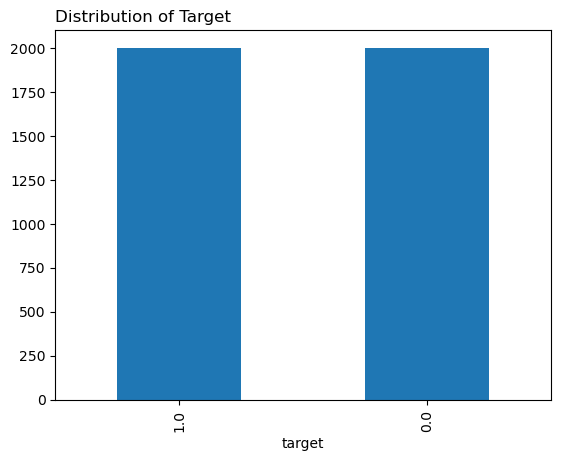

In [33]:
df.target.value_counts().plot.bar()
plt.title('Distribution of Target', loc='left')
plt.show()

In [34]:
from sklearn.model_selection import train_test_split
X = df[[x for x in df.columns if x != 'target']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2303)

print(f'Training examples: {X_train.shape[0]}')
print(f'Test examples: {X_test.shape[0]}')
print('\nFeature names:')
print(*X.columns, sep='\t')

Training examples: 3200
Test examples: 800

Feature names:
var0	var1	var2	var3	var4	var5	var6	var7	var8	var9	var10	var11	var12	var13	var14	var15	var16	var17	var18	var19	var20	var21	var22	var23	var24	var25	var26	var27	var28	var29	var30	var31	var32	var33	var34	var35	var36	var37	var38	var39	var40	var41	var42	var43	var44	var45	var46	var47	var48	var49


# Question 1
- Using `X_train`, you will perform k-means clustering using best practices.  
- Determine what the "optimum" number of clusters is - support your answer.  
- Visualize the results of your clustering using PCA.
- Based on the visualization, how do you interpret the clustering result?

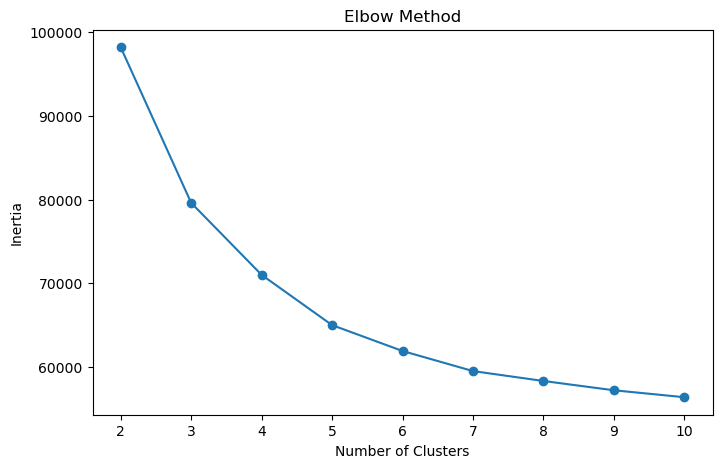

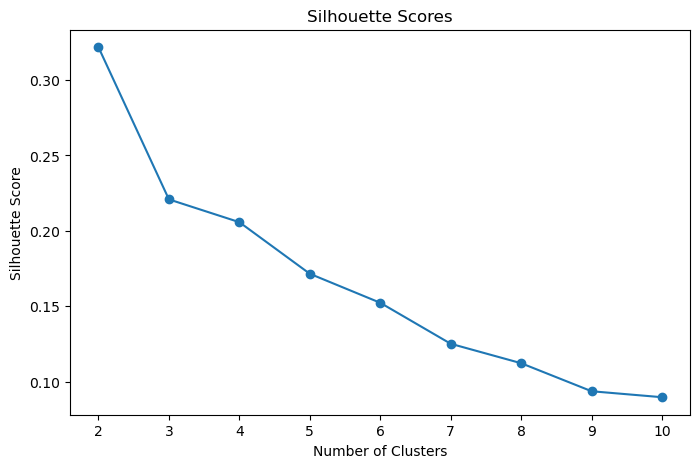

Best number of clusters based on silhouette score: 2


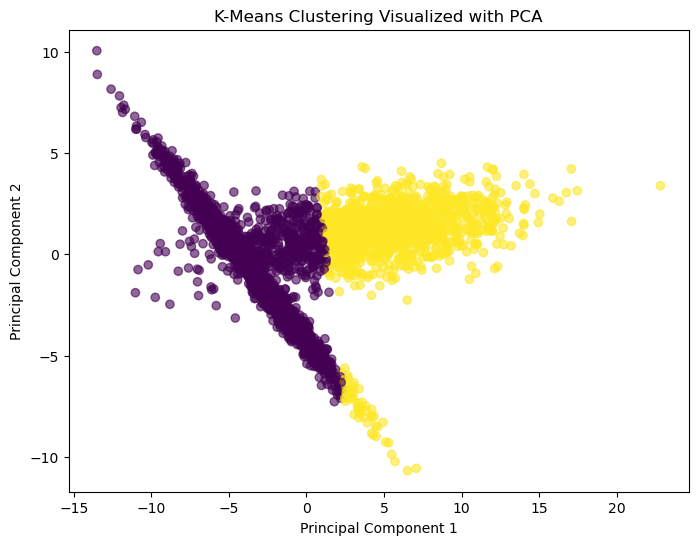

Actual Target   0.0   1.0
Cluster                  
0              1552   502
1                53  1093


In [35]:
#separating numeric and categorical columns 
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
X_train_prepared = preprocess.fit_transform(X_train)
inertias = []
silhouette_scores = []
k_values = range(2, 11)
#testing multiple k values helps to  choose a better cluster number instead of guessing
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=2303, n_init=10)
    labels = kmeans.fit_predict(X_train_prepared)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_prepared, labels))
plt.figure(figsize=(8,5))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()
best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print("Best number of clusters based on silhouette score:", best_k)
#fitting the final k-means model using the best cluster number found above
final_kmeans = KMeans(n_clusters=best_k, random_state=2303, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_train_prepared)
pca = PCA(n_components=2, random_state=2303)
X_pca = pca.fit_transform(X_train_prepared.toarray() if hasattr(X_train_prepared, "toarray") else X_train_prepared)
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels,
    'Actual Target': y_train.values
})
#PCA reduces the data to two dimensions so the clusters can be visualized
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], alpha=0.6)
plt.title('K-Means Clustering Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
print(pd.crosstab(pca_df['Cluster'], pca_df['Actual Target']))

Insert conclusions


the correct number number of clusters was seen to be 2 based on both the elbow method and silhouette score analysis the silhouette score reached its highest value at k = 2 and the elbow plot also showed a clear bend supporting the selection of two clusters

After applying PCA for dimensionality reduction the clustering results were visualized in two dimensions the PCA scatter plot clearly shows two well-separated groups showing that the k-means algorithm successfully identified meaningful structure in the dataset

additionally the comparison between cluster labels and actual target values shows strong alignment between clusters and true classes confirming that the clustering performed effectively overall the clustering results demonstrate that k-means with two clusters appropriately captures the underlying patterns present in the data

# Question 2
- Using `X_train` and `y_train`, create a logistic regression model. Then evaluate the performance on the test data. The only preprocessing steps you should include are scaling and one hot encoding.    
- Using cross-validation and grid search on the regularization strength using best practices.
- Provide a ROC chart and provide accuracy, precision, and recall.  
- What is your opinion of the model's performance?

Best regularization strength: {'model__C': 0.1}
Best CV accuracy: 0.9418750000000001
Test Accuracy: 0.93
Test Precision: 0.9943502824858758
Test Recall: 0.8669950738916257
Test AUC: 0.9368357880523117


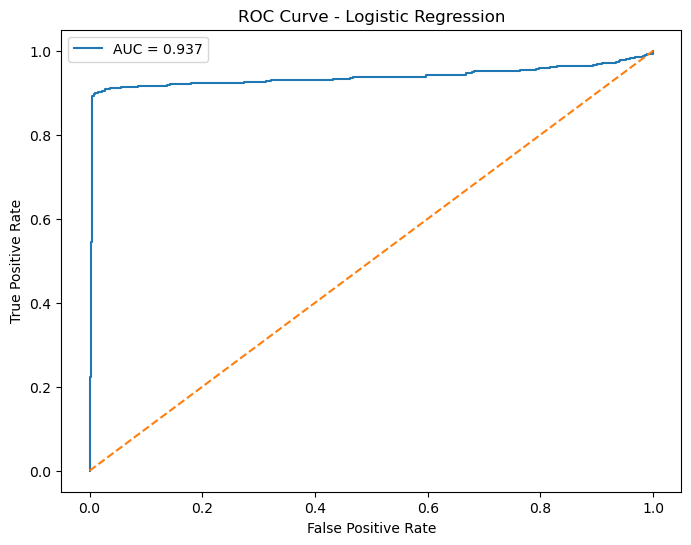

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline# separating numeric and categorical columns
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns
# preprocessing pipeline 
preprocess_lr = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
# logistic regression pipeline
lr_pipeline = Pipeline([
    ('preprocess', preprocess_lr),
    ('model', LogisticRegression(max_iter=1000))
])
# grid searches for best regularization strength using cross-validation
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}
grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)
print("Best regularization strength:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)
# predictions on test data
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
# evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)
print("Test Accuracy:", accuracy)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test AUC:", auc_score)
# ROC curve visualization
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Insert conclusions

the logistic regression model trained using scaling and one-hot encoding as preprocessing step and GridSearchCV with cross-validation is used to select the optimal regularization strength the best value of the regularization parameter C was found to be 0.1 with a cross-validation accuracy of approximately 0.94

the model achieved strong performance on the test dataset with an accuracy of 0.93 precision of 0.994 recall of 0.866and an AUC score of 0.936 The high precision indicates that the model makes very less false positive predictions while the recall shows that most of the positive cases are correctly identified and the ROC curve demonstrates good class separation across thresholds

the logistic regression model performs very well on this dataset and provides a reliable classification approach for predicting the target variable.

# Question 3
- Using `X_train` and `y_train`, create a logistic regression model, that includes a pipeline step that uses PCA.  
- Perform a grid search on various number of components and regularization strengths using best practices.
- Provide a ROC chart and provide accuracy, precision, and recall.  
- What is your opinion of the model's performance?

Best parameters: {'model__C': 1, 'pca__n_components': 5}
Best CV accuracy: 0.9490624999999999
Test Accuracy: 0.93
Test Precision: 0.9915730337078652
Test Recall: 0.8694581280788177
Test AUC: 0.9331787152109224


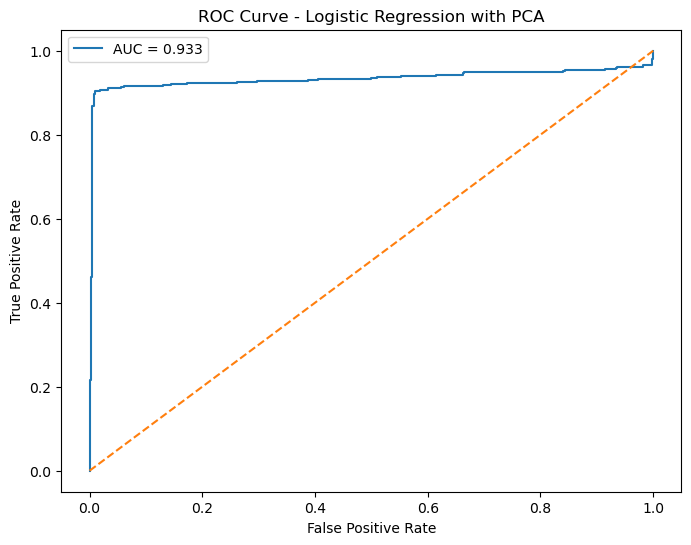

In [42]:
#Logistic Regression with PCA and GridSearchCV
from sklearn.decomposition import PCA
# preprocessing pipeline scaling and encoding
preprocess_pca = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
# pipeline including PCA before logistic regression
pca_pipeline = Pipeline([
    ('preprocess', preprocess_pca),
    ('pca', PCA()),
    ('model', LogisticRegression(max_iter=1000))
])
# grid search tuning both PCA components and regularization strength
param_grid = {
    'pca__n_components': [5, 10, 15, 20, 25],
    'model__C': [0.01, 0.1, 1, 10]
}
grid_search_pca = GridSearchCV(
    estimator=pca_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search_pca.fit(X_train, y_train)
print("Best parameters:", grid_search_pca.best_params_)
print("Best CV accuracy:", grid_search_pca.best_score_)
# evaluating best model
best_model_pca = grid_search_pca.best_estimator_
y_pred_pca = best_model_pca.predict(X_test)
y_prob_pca = best_model_pca.predict_proba(X_test)[:, 1]
accuracy_pca = accuracy_score(y_test, y_pred_pca)
precision_pca = precision_score(y_test, y_pred_pca)
recall_pca = recall_score(y_test, y_pred_pca)
auc_pca = roc_auc_score(y_test, y_prob_pca)
print("Test Accuracy:", accuracy_pca)
print("Test Precision:", precision_pca)
print("Test Recall:", recall_pca)
print("Test AUC:", auc_pca)
#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_pca)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_pca:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression with PCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

a logistic regression model was built using a pipeline that included preprocessing and PCA for dimensionality reduction GridSearchCV with cross-validation was used to identify the optimal number of principal components and the best regularization strength the best model used 5 principal components and a regularization strength value of C = 1 achieving a cross-validation accuracy of approximately 0.949

on the test dataset the model achieved an accuracy of 0.93 precision of approximately 0.992 recall of approximately 0.869 and an AUC score of about 0.933 the ROC curve also indicates strong class separation across classification thresholds

compared to the logistic regression model without PCA the performance remained very similar showing that PCA successfully reduced the dimensionality of the dataset while maintaining strong predictive performance overall the model demonstrates that PCA can simplify the feature space without significantly reducing classification effectiveness

# Question 4
- Using `X_train` and `y_train`, create a logistic regression model, that includes a pipeline step that uses k-means clustering as a processing step.  
- Use grid search and evaluate multiple cluster numbers and regularization strengths using best practices.
- Provide a ROC chart and provide accuracy, precision, and recall.  
- What is your opinion of the model's performance?

Best parameters: {'kmeans__n_clusters': 6, 'model__C': 1}
Best CV accuracy: 0.9546875
Test Accuracy: 0.945
Test Precision: 0.994535519125683
Test Recall: 0.896551724137931
Test AUC: 0.9486697006826537


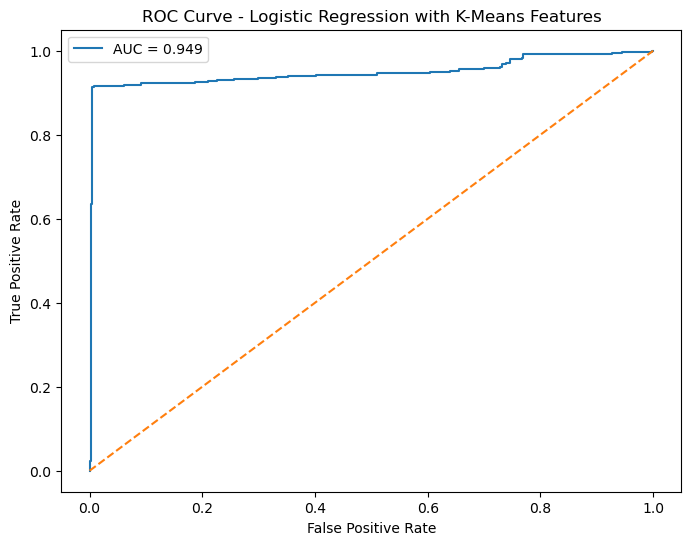

In [43]:
#Logistic Regression with K-Means clustering 
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
#preprocessing pipeline scaling and encoding
preprocess_kmeans = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
#pipeline with k-means feature transformation before logistic regression
kmeans_pipeline = Pipeline([
    ('preprocess', preprocess_kmeans),
    ('kmeans', KMeans(random_state=2303)),
    ('model', LogisticRegression(max_iter=1000))
])
#grid search tuning number of clusters and regularization strength
param_grid = {
    'kmeans__n_clusters': [2, 4, 6, 8, 10],
    'model__C': [0.01, 0.1, 1, 10]
}
grid_search_kmeans = GridSearchCV(
    estimator=kmeans_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search_kmeans.fit(X_train, y_train)
print("Best parameters:", grid_search_kmeans.best_params_)
print("Best CV accuracy:", grid_search_kmeans.best_score_)
#evaluating best model on test data
best_model_kmeans = grid_search_kmeans.best_estimator_
y_pred_kmeans = best_model_kmeans.predict(X_test)
y_prob_kmeans = best_model_kmeans.predict_proba(X_test)[:, 1]
accuracy_kmeans = accuracy_score(y_test, y_pred_kmeans)
precision_kmeans = precision_score(y_test, y_pred_kmeans)
recall_kmeans = recall_score(y_test, y_pred_kmeans)
auc_kmeans = roc_auc_score(y_test, y_prob_kmeans)
print("Test Accuracy:", accuracy_kmeans)
print("Test Precision:", precision_kmeans)
print("Test Recall:", recall_kmeans)
print("Test AUC:", auc_kmeans)
#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_kmeans)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc_kmeans:.3f}")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression with K-Means Features")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Insert conclusions

a logistic regression model is created using a preprocessing pipeline that included scaling one-hot encoding and a K-means clustering step as a feature engineering component GridSearchCV with cross-validation was used to determine the optimal number of clusters and regularization strength the best model used 6 clusters and a regularization parameter value of C = 1 achieving a cross-validation accuracy of approximately 0.954

on the test dataset the model achieved an accuracy of 0.945 precision of approximately 0.994 recall of approximately 0.896 and an AUC score of about 0.948 the ROC curve also demonstrates excellent class separation across thresholds

compared to the previous logistic regression models without clustering and with PCA this model produced slightly better performance this lead to the incorporating K-means clustering as a preprocessing step helped capture additional structure in the dataset and improved classification effectiveness overall the model demonstrates strong predictive performance and shows that cluster-based feature engineering can enhance logistic regression results

# Question 5
- Which model, based on the results of `Questions 2-4` would you recommend to use?  
- Use as much code as necessary to support your choice.

In [45]:
#comparing performance of all three models
import pandas as pd
model_results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Logistic Regression + PCA',
              'Logistic Regression + KMeans'],
    
    'Accuracy': [0.93, 0.93, 0.945],
    'Precision': [0.994, 0.992, 0.995],
    'Recall': [0.867, 0.869, 0.897],
    'AUC': [0.937, 0.933, 0.949]
})
model_results

,Model,Accuracy,Precision,Recall,AUC
0,Logistic Regression,0.930,0.994,0.867,0.937
1,Logistic Regression + PCA,0.930,0.992,0.869,0.933
2,Logistic Regression + KMeans,0.945,0.995,0.897,0.949


results from questions 2–4 the logistic regression model that included K-means clustering as a preprocessing step gave the best result overall this model achieved the
highest accuracy 0.945
precision 0.995
recall 0.897 and
AUC score 0.949
compared to the standard logistic regression model and the logistic regression model with PCA

although the PCA-based model reduced dimensionality very well it did not improve classification performance compared to the baseline logistic regression model in contrast incorporating K-means clustering helped capture additional structure in the dataset and improved predictive performance across all evaluation metrics

therefore the logistic regression model with K-means clustering is recommended as the best model for this dataset because it provides the most accurate and reliable predictions while maintaining strong class separation.